In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
import xgboost as xgb

In [2]:
leukemia = fetch_openml(name="leukemia", version=1, as_frame=True)

X = leukemia.data
y = leukemia.target

print("Dataset loaded")
print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

Dataset loaded
X shape: (72, 7129)
y shape: (72,)
CLASS
ALL    47
AML    25
Name: count, dtype: int64


In [3]:
y_encoded = y.map({"ALL": 0, "AML": 1})

print(y_encoded.value_counts())

CLASS
0    47
1    25
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 57
Testing samples: 15


In [5]:
model = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained")

C:\Users\malla022\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:25:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model trained


In [6]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       1.00      0.80      0.89         5

    accuracy                           0.93        15
   macro avg       0.95      0.90      0.92        15
weighted avg       0.94      0.93      0.93        15



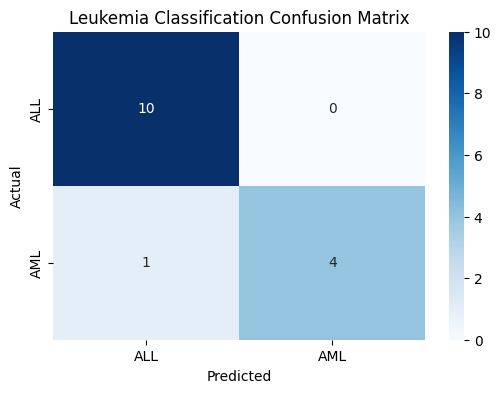

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["ALL","AML"],
    yticklabels=["ALL","AML"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Leukemia Classification Confusion Matrix")

plt.show()

In [8]:
importances = model.feature_importances_

feature_importance = pd.DataFrame({
    "Gene": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Gene,Importance
6854,M31523_at,0.312637
1833,M23197_at,0.186899
1881,M27891_at,0.163405
2287,M84526_at,0.150370
3251,U46499_at,0.077437
6040,L09209_s_at,0.045184
4376,X62654_rna1_at,0.028337
38,AFFX-HUMRGE/M10098_5_at,0.013114
166,D00726_at,0.010905
3,AFFX-BioC-5_at,0.008099


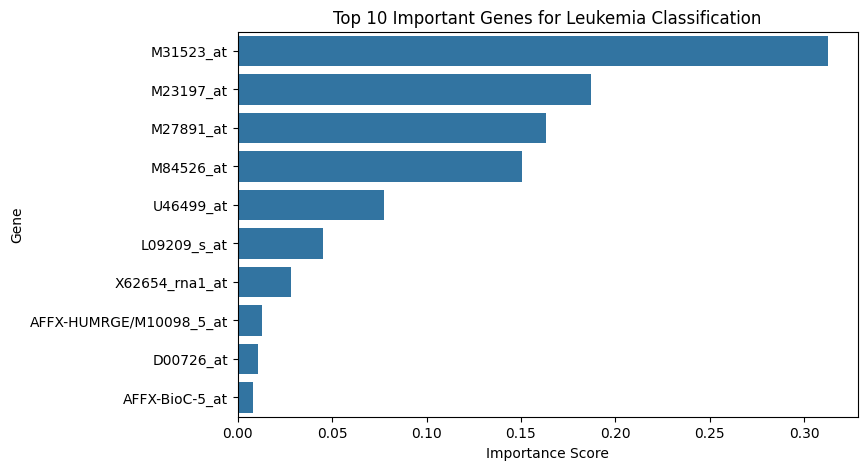

In [9]:
top_genes = feature_importance.head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=top_genes, x="Importance", y="Gene")

plt.title("Top 10 Important Genes for Leukemia Classification")
plt.xlabel("Importance Score")
plt.ylabel("Gene")

plt.show()

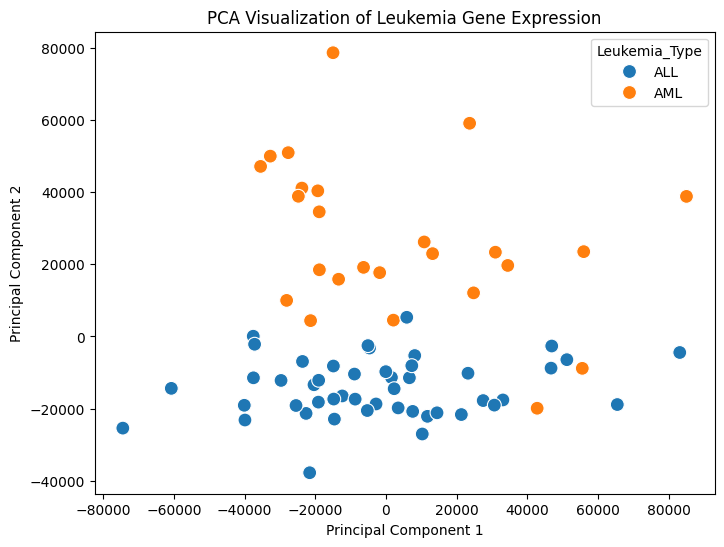

In [10]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(X_pca, columns=["PC1","PC2"])
pca_df["Leukemia_Type"] = y

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Leukemia_Type",
    s=100
)

plt.title("PCA Visualization of Leukemia Gene Expression")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [11]:
# select top 100 genes based on importance
top_100_genes = feature_importance.head(100)["Gene"]

X_top = X[top_100_genes]

print("Original feature count:", X.shape[1])
print("Reduced feature count:", X_top.shape[1])

Original feature count: 7129
Reduced feature count: 100


In [12]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_top, y_encoded, test_size=0.2, random_state=42
)

model2 = xgb.XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

model2.fit(X_train2, y_train2)

print("Model trained using top 100 genes")

Model trained using top 100 genes


In [13]:
y_pred2 = model2.predict(X_test2)

accuracy2 = accuracy_score(y_test2, y_pred2)

print("Accuracy with Top 100 Genes:", accuracy2)
print(classification_report(y_test2, y_pred2))

Accuracy with Top 100 Genes: 0.9333333333333333
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       1.00      0.80      0.89         5

    accuracy                           0.93        15
   macro avg       0.95      0.90      0.92        15
weighted avg       0.94      0.93      0.93        15

